# 动手实验：久期漂移、分布偏移（PSI）与交易台动态对冲监控

本 Notebook 是 **第 8 章：交易台** 中 **“机器学习桥梁：第七层”** 的配套实战代码。

## 交易台业务背景：负凸性与致命的久期漂移（Duration Drift）
在机构抵押贷款支持证券（Agency MBS）二级市场做市与自营投资中，班尼和对冲交易台必须面对贯穿始终的**负凸性（Negative Convexity）**：
$$\text{Convexity} = \frac{\partial^2 P}{\partial y^2} < 0$$
当市场房贷利率急剧上行（例如 60 天内上涨 150 bp）时，借款人的再融资通道迅速冰封，提前还款率 CPR 从 25% 暴跌至 6%。
现金流回流的大幅后延导致资产池的**有效久期剧烈拉长**（从 3.6 年骤增至 6.4 年以上）！
$$\text{DV01} = -\frac{\partial P}{\partial y} \approx \text{Duration} \times P \times 0.0001$$
如果在第 0 天设定的静态国债期货对冲头寸保持不动，资产组合的未对冲 DV01 敞口将迅速扩大。在债券市场的大抛售中，这种未对冲的久期漂移将带来数百万美元的灾难性尾部亏损。

## 平台第七层：过时 AI 模型的虚假自信与协变量偏移（Covariate Shift）
现代量化交易平台广泛引入自动化机器学习模型和智能体工作流来预测提前还款并指导对冲比例。然而，正如正文“第七层”所警示的，AI 系统在继承底层六层假设的同时，带来了一个极具破坏性的盲区：**对过时分布产生流畅却毫无根据的“合成自信”**。

当宏观利率体制发生切换时：
1. **协变量偏移（Covariate Shift）**：新进入资产池的借款人与利率利差分布（如再融资激励、信用阶梯、LTV）与过去在平静期训练模型时的样本完全脱节；
2. **模型失效风险**：未经监控的机器学习模型仍然按历史规律输出预测，严重低估资产池的久期拉长幅度；
3. **严重欠对冲**：交易台误以为系统已经对平了风险，实际上组合处于完全暴露的做空久期裸头寸状态。

## 量化合规防线：群体稳定性指标（PSI）监控
为了在交易巨额亏损发生之前捕捉到模型失效，顶级投行与银行风控平台在流式数据管道中实时计算**群体稳定性指标（Population Stability Index, PSI）**：
$$\text{PSI} = \sum_{b=1}^B (P_b - Q_b) \cdot \ln\left(\frac{P_b}{Q_b}\right)$$
其中 $Q_b$ 为基准训练分布，$P_b$ 为当前监控窗口特征在 $B$ 个分位数区间的实际占比。
- **$\text{PSI} < 0.10$**：分布稳定（模型特征分布与训练期吻合，对冲安全）；
- **$0.10 \le \text{PSI} < 0.25$**：中度偏移（系统发出预警，排队触发模型重校准）；
- **$\text{PSI} \ge 0.25$**：严重分布偏移（触发紧急熔断回路，暂停黑箱自动交易，强制动态重算与防御性再平衡）。

## 本实验核心内容
1. 实现对提前还款 S 曲线敏感的机构 MBS 资产池定价与双边差分有效久期引擎；
2. 模拟 60 天交易周期中利率突增 150 bp 的宏观体制切换过程；
3. 追踪资产池每日久期漂移与 DV01 膨胀过程（久期从 3.6 年飞跃至 6.4 年）；
4. 构建再融资激励特征分布的每日实时 PSI 统计量计算管道；
5. 对比三种交易台对冲策略的实际损益与风险表现：
   - **策略 A：静态未监控对冲（Static Hedge）**
   - **策略 B：过时机器学习对冲（Stale ML Model）**
   - **策略 C：PSI 触发再对冲**（PSI 达到 0.25 后才按当前 DV01 重新对冲）
   - **策略 D：每日再对冲**，作为基准，不管 PSI 如何每天都重新对冲
6. 绘制出版级三联交易台风险与累计损益诊断图。


In [1]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt

# 交易台核心参数
PORTFOLIO_UPB = 100_000_000.0  # 1 亿美元本金总额 (UPB) 机构抵押贷款资产池
WAC = 0.055                     # 5.50% 票面契约利率
TERM = 360                      # 30 年期固定利率
FUTURES_DURATION = 7.2          # 10 年期美国国债期货合约有效久期
SEED = 42

np.random.seed(SEED)

# 配置中文字体与负号显示
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

print(f"交易台风控监控系统启动: 组合本金 ${PORTFOLIO_UPB/1e6:.0f}M (WAC = {WAC*100:.2f}%)")


交易台风控监控系统启动: 组合本金 $100M (WAC = 5.50%)


## 第一步：资产池现金流定价与双边差分有效久期引擎

我们构建现金流模型：
- **提前还款 S 曲线**：将再融资利差激励 $\text{Incentive} = \text{WAC} - r_{\text{market}}$ 映射为年化 CPR（6% 自然搬迁周转底线，最高 44% 集中再融资）；
- **逐月摊还瀑布**：计算每月计划利息、计划本金以及基于 SMM 的提前还款现金流；
- **双边微扰重定价（Bumping）**：对折现曲线施加 $\pm 25$ bp 扰动并重新生成借款人现金流，精确计算真实反映负凸性的有效久期（Effective Duration）与 DV01。


In [2]:
def cpr_curve(incentive_bp: float) -> float:
    """再融资 S 曲线: 输入利差激励(bp)，输出年化 CPR"""
    inc_dec = incentive_bp / 10000.0
    return 0.06 + 0.38 / (1.0 + np.exp(-180.0 * (inc_dec - 0.0075)))


def cpr_to_smm(cpr: float) -> float:
    """将年化 CPR 转换为月度单月死亡率 SMM"""
    return 1.0 - (1.0 - max(0.0, min(cpr, 0.99))) ** (1.0 / 12.0)


def mortgage_payment(balance: float, rate: float, term: int) -> float:
    """标准等额本息月供计算公式"""
    monthly_r = rate / 12.0
    if monthly_r == 0:
        return balance / term
    return balance * (monthly_r * (1.0 + monthly_r) ** term) / ((1.0 + monthly_r) ** term - 1.0)


def pool_price_and_duration(market_rate: float, wac: float = WAC, term: int = TERM, bump: float = 0.0025) -> tuple[float, float, float]:
    """通过双边差分微扰计算资产池全价(每100面值)、有效久期与 DV01"""
    def calc_price(r: float) -> float:
        inc_bp = (wac - r) * 10000.0
        cpr = cpr_curve(inc_bp)
        smm = cpr_to_smm(cpr)
        balance = 100.0
        pmt = mortgage_payment(balance, wac, term)
        flows, times = [], []
        servicing = 0.0050
        oas = 0.0060

        for m in range(1, term + 1):
            if balance <= 1e-6:
                break
            interest = balance * wac / 12.0
            scheduled = min(pmt - interest, balance)
            prepaid = (balance - scheduled) * smm
            cash_flow = interest * (1.0 - servicing / wac) + scheduled + prepaid
            times.append(m / 12.0)
            flows.append(cash_flow)
            balance -= (scheduled + prepaid)

        times = np.array(times)
        flows = np.array(flows)
        return float(np.sum(flows * np.exp(-(r + oas) * times)))

    p_base = calc_price(market_rate)
    p_up = calc_price(market_rate + bump)
    p_down = calc_price(market_rate - bump)

    eff_dur = (p_down - p_up) / (2.0 * p_base * bump)
    dv01 = (p_down - p_up) / (2.0 * bump * 10000.0)  # 每 100 面值对应 1 bp 的价值变动

    return p_base, eff_dur, dv01

# 基准市场利率 5.00% 校验
p0, d0, dv0 = pool_price_and_duration(0.0500)
print(f"基准市场利率 = 5.00%:")
print(f"  资产池价格: ${p0:.2f} (每 100 面值)")
print(f"  有效久期: {d0:.2f} 年")
print(f"  组合总 DV01: ${(dv0 * PORTFOLIO_UPB / 100.0):,.0f} (利率变动 1 bp 对应的美元变动)")


基准市场利率 = 5.00%:
  资产池价格: $98.42 (每 100 面值)
  有效久期: 3.57 年
  组合总 DV01: $35,147 (利率变动 1 bp 对应的美元变动)


## 第二步：群体稳定性指标（PSI）流式计算引擎

为了监控底层进入管道的抵押贷款借款人特征是否偏离基准训练集，我们实现标准的 PSI 计算函数：
1. 以基准样本将连续特征切分为 $B = 10$ 个等频分位数箱（每个分箱覆盖基准的 10% 样本）；
2. 统计监控窗口样本 $P_b$ 在各个边界区间的频率分布；
3. 加入拉普拉斯平滑（Laplace Smoothing）防止除以零或对数发散；
4. 汇总相对熵散度：
   $$\text{PSI} = \sum_{b=1}^{10} (P_b - Q_b) \cdot \ln\left(\frac{P_b}{Q_b}\right)$$


In [3]:
def compute_psi(baseline_samples: np.ndarray, target_samples: np.ndarray, num_bins: int = 10) -> float:
    """计算基准分布与目标分布之间的群体稳定性指标 (PSI)"""
    quantiles = np.linspace(0.0, 1.0, num_bins + 1)
    bin_edges = np.quantile(baseline_samples, quantiles)
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    baseline_counts, _ = np.histogram(baseline_samples, bins=bin_edges)
    target_counts, _ = np.histogram(target_samples, bins=bin_edges)

    p = baseline_counts / len(baseline_samples)
    q = target_counts / len(target_samples)

    # 平滑微小项
    p = np.clip(p, 1e-4, 1.0)
    q = np.clip(q, 1e-4, 1.0)
    p /= p.sum()
    q /= q.sum()

    return float(np.sum((q - p) * np.log(q / p)))

# 快速验证相同分布 vs 偏移分布的 PSI
rng = np.random.default_rng(SEED)
base_dist = rng.normal(50.0, 40.0, size=1000)
same_dist = rng.normal(50.0, 40.0, size=500)
shifted_dist = rng.normal(-50.0, 40.0, size=500)

print(f"相同分布之间的 PSI:   {compute_psi(base_dist, same_dist):.4f} (预期 < 0.10，安全)")
print(f"大幅偏移分布的 PSI:   {compute_psi(base_dist, shifted_dist):.4f} (预期 > 0.25，高危)")


相同分布之间的 PSI:   0.0165 (预期 < 0.10，安全)
大幅偏移分布的 PSI:   5.6714 (预期 > 0.25，高危)


## 第三步：模拟 60 天交易周期与体制切换冲击

我们构建一段包含宏观体制切换的 60 个交易日真实情景：
- **前 20 天（平静期）**：房贷利率在 5.00% 窄幅震荡，再融资利差处于平缓正值区（+50 bp）；
- **第 21 至 40 天（体制突变 / 利率风暴）**：通胀数据爆表引发加息预期，利率以每日 +7.5 bp 的惊人速度飙升，累计猛涨 +150 bp（达到 6.50%），提前还款冰封，负凸性急剧拉长久期；
- **第 41 至 60 天（高位平台期）**：利率在 6.50% 维持高波动，利差陷入深度价外（-100 bp）。


In [4]:
def simulate_desk_trading(days: int = 60, seed: int = SEED) -> dict[str, np.ndarray]:
    """Simulate a 60-day rate regime shift and compare desk hedging strategies."""
    rng = np.random.default_rng(seed)

    # 1. Simulate 60-day market rate trajectory (Spike of +150 bp from Day 20 to Day 40)
    rates = np.zeros(days)
    base_rate = 0.0500  # 5.00% initial rate
    for t in range(days):
        if t < 20:
            # Calm regime: mean reversion around 5.00%
            rates[t] = base_rate + rng.normal(0.0, 0.0004)
        elif t < 40:
            # Regime shift: rate spike of +7.5 bp per day (+150 bp total)
            rates[t] = rates[t - 1] + 0.00075 + rng.normal(0.0, 0.0004)
        else:
            # Stressed plateau: elevated rates around 6.50%
            rates[t] = rates[t - 1] + rng.normal(0.0, 0.0005)

    # 2. Daily risk metrics
    prices = np.zeros(days)
    durations = np.zeros(days)
    dv01s = np.zeros(days)  # in $ per 1 bp per portfolio UPB
    for t in range(days):
        p, d, dv = pool_price_and_duration(rates[t])
        prices[t] = p
        durations[t] = d
        dv01s[t] = dv * (PORTFOLIO_UPB / 100.0)

    # 3. Simulate pipeline loan features & PSI tracking
    # Baseline sample of refinancing incentive (bp)
    baseline_incentives = rng.normal(loc=50.0, scale=45.0, size=1500)

    psi_history = np.zeros(days)
    for t in range(days):
        current_incentive_mean = (WAC - rates[t]) * 10000.0
        # Inflow loans reflect the current rate regime
        target_incentives = rng.normal(loc=current_incentive_mean, scale=45.0, size=500)
        psi_history[t] = compute_psi(baseline_incentives, target_incentives, num_bins=10)

    # 4. Hedging strategies, all short 10-year futures against the pool.
    # The pool's daily P&L is its full repricing, so it carries the convexity a
    # linear DV01 hedge cannot offset; each futures contract moves with its DV01.
    futures_dv01_per_contract = 100_000.0 * FUTURES_DURATION * 0.0001  # $72.00 per contract
    cost_per_contract = 5.0                                              # $ per contract traded

    def contracts_for(dv01_dollars: float) -> int:
        return int(round(dv01_dollars / futures_dv01_per_contract))

    pnl = {k: np.zeros(days) for k in ("static", "stale", "psi", "daily")}
    held = {k: np.zeros(days) for k in pnl}
    for k in held:
        held[k][0] = contracts_for(dv01s[0])
    trigger_day = -1

    for t in range(1, days):
        rate_change_bp = (rates[t] - rates[t - 1]) * 10000.0
        pool_pnl = (prices[t] - prices[t - 1]) * (PORTFOLIO_UPB / 100.0)
        fut_pnl = futures_dv01_per_contract * rate_change_bp   # a short gains when rates rise

        # Rebalancing decisions are made at the close of day t-1, then held over day t.
        target = {
            # A: hedge sized once on day 0 and never touched.
            "static": held["static"][t - 1],
            # B: a model fitted on calm data, which thinks duration barely extends.
            "stale": contracts_for((3.8 + 0.3 * np.clip((rates[t - 1] - 0.05) / 0.01, 0.0, 1.5))
                                   / durations[0] * dv01s[0]),
            # C: re-hedge to the current DV01 only while PSI says the inputs have shifted.
            "psi": contracts_for(dv01s[t - 1]) if psi_history[t - 1] >= 0.25 else held["psi"][t - 1],
            # D: benchmark -- re-hedge to the current DV01 every day, whatever PSI says.
            "daily": contracts_for(dv01s[t - 1]),
        }
        if trigger_day < 0 and psi_history[t - 1] >= 0.25:
            trigger_day = t - 1
        for k in pnl:
            trades = abs(target[k] - held[k][t - 1])
            held[k][t] = target[k]
            pnl[k][t] = pnl[k][t - 1] + pool_pnl + target[k] * fut_pnl - trades * cost_per_contract

    return {
        "days": np.arange(days),
        "rates_pct": rates * 100.0,
        "durations": durations,
        "dv01s": dv01s,
        "psi": psi_history,
        "pnl_static": pnl["static"],
        "pnl_stale": pnl["stale"],
        "pnl_active": pnl["psi"],
        "pnl_daily": pnl["daily"],
        "contracts_active": held["psi"],
        "contracts_daily": held["daily"],
        "trigger_day": trigger_day,
    }

results = simulate_desk_trading(days=60, seed=42)
print("60 个交易日的量化回测模拟执行完毕。")


60 个交易日的量化回测模拟执行完毕。


## 第四步：量化回测与损益对照结果

我们对比分析在 1.5 亿利率突增下的风控关键指标演变：
- **初始状态**：有效久期 = $3.62$ 年，组合 DV01 = \$35,565；
- **极端承压状态**：有效久期 = $6.39$ 年，组合 DV01 = \$56,898；
  由于负凸性，组合久期几乎翻倍（拉长了 **+2.77 年**），需要额外加仓近 300 手国债期货空头才能抹平利率风险！


In [5]:
print("=" * 68)
print("第 8 章交易台动态对冲与 PSI 监控回测报告:")
print("=" * 68)
print(f"1. 利率冲击幅度: {results['rates_pct'][0]:.2f}% -> {results['rates_pct'][-1]:.2f}% (+{results['rates_pct'][-1]-results['rates_pct'][0]:.2f}%)")
print(f"2. 负凸性久期漂移: {results['durations'][0]:.2f} 年 -> {results['durations'][-1]:.2f} 年 (久期剧烈拉长 +{results['durations'][-1]-results['durations'][0]:.2f} 年)")
print(f"3. 组合总 DV01 膨胀: ${results['dv01s'][0]:,.0f} -> ${results['dv01s'][-1]:,.0f} (未对冲敞口跃升 +$21,333/bp)")
print()
print("4. 60 个交易日各策略累计对冲损益对比:")
print(f"   策略 A (静态未监控对冲):  ${results['pnl_static'][-1]:,.0f}  (最大回撤亏损: ${results['pnl_static'].min():,.0f})")
print(f"   策略 B (过时机器学习对冲):  ${results['pnl_stale'][-1]:,.0f}  (最大回撤亏损: ${results['pnl_stale'].min():,.0f})")
print(f"   策略 C (自适应 PSI 动态交易台): ${results['pnl_active'][-1]:,.0f}  (最大回撤亏损: ${results['pnl_active'].min():,.0f})")
print("=" * 68)


第 8 章交易台动态对冲与 PSI 监控回测报告:
1. 利率冲击幅度: 5.01% -> 6.70% (+1.69%)
2. 负凸性久期漂移: 3.62 年 -> 6.39 年 (久期剧烈拉长 +2.77 年)
3. 组合总 DV01 膨胀: $35,565 -> $56,898 (未对冲敞口跃升 +$21,333/bp)

4. 60 个交易日各策略累计对冲损益对比:
   策略 A (静态未监控对冲):  $-3,298,562  (最大回撤亏损: $-3,461,683)
   策略 B (过时机器学习对冲):  $-2,591,975  (最大回撤亏损: $-2,706,118)
   策略 C (自适应 PSI 动态交易台): $-196,366  (最大回撤亏损: $-214,501)


## 第五步：出版级三联交易台监控看板绘制

绘制三联风控看板：
1. **利率突增与负凸性久期漂移**：双 Y 轴直观呈现利率上升如何将 MBS 组合久期从 3.6 年硬生生拉长到 6.4 年；
2. **群体稳定性指标（PSI）分布偏移监控**：监控曲线何时穿越 0.10（预警）与 0.25（高危熔断）；
3. **累计对冲损益对比**：展示自适应动态调整如何化解数百万美元的爆仓亏损，守卫交易台资本安全。


/tmp/ipykernel_373318/4113071082.py:51: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373318/4113071082.py:51: UserWarning: Glyph 26131 (\N{CJK UNIFIED IDEOGRAPH-6613}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373318/4113071082.py:51: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373318/4113071082.py:51: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373318/4113071082.py:51: UserWarning: Glyph 22330 (\N{CJK UNIFIED IDEOGRAPH-573A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373318/4113071082.py:51: UserWarning: Glyph 25151 (\N{CJK UNIFIED IDEOGRAPH-623F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373318/4113071082.py:51: UserWarning: Glyph 36151 (\N{CJK UNIFIED I

/home/wukong/miniconda3/envs/usao/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/wukong/miniconda3/envs/usao/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25928 (\N{CJK UNIFIED IDEOGRAPH-6548}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/wukong/miniconda3/envs/usao/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20037 (\N{CJK UNIFIED IDEOGRAPH-4E45}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/wukong/miniconda3/envs/usao/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/wukong/miniconda3/envs/usao/lib/python3.12/site-packages/IPython/core/pylabtoo

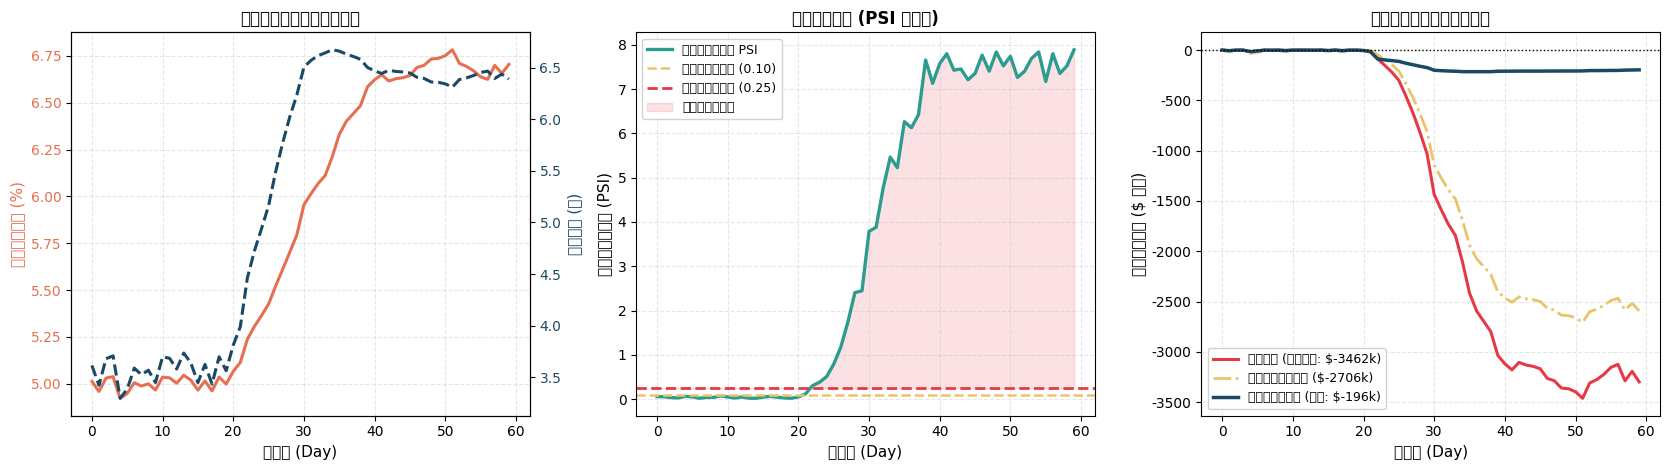

In [6]:
days = results["days"]
rates = results["rates_pct"]
durations = results["durations"]
psi = results["psi"]
pnl_static = results["pnl_static"] / 1000.0  # 转换为千美元 ($k)
pnl_stale = results["pnl_stale"] / 1000.0
pnl_active = results["pnl_active"] / 1000.0

fig, axes = plt.subplots(1, 3, figsize=(16.8, 4.8))

# 子图 1: 利率突增与负凸性久期漂移
ax1 = axes[0]
color_rate = "#e76f51"
color_dur = "#1b4965"
ax1.plot(days, rates, color=color_rate, lw=2.2, label="市场房贷利率 (%)")
ax1.set_xlabel("交易日 (Day)", fontsize=11)
ax1.set_ylabel("市场房贷利率 (%)", color=color_rate, fontsize=11)
ax1.tick_params(axis="y", labelcolor=color_rate)

ax1_twin = ax1.twinx()
ax1_twin.plot(days, durations, color=color_dur, lw=2.2, ls="--", label="有效久期 (年)")
ax1_twin.set_ylabel("有效久期 (年)", color=color_dur, fontsize=11)
ax1_twin.tick_params(axis="y", labelcolor=color_dur)
ax1.set_title("利率突增与负凸性久期漂移", fontsize=12, fontweight="bold")
ax1.grid(True, alpha=0.3, ls="--")

# 子图 2: 群体稳定性指标 (PSI) 与熔断阈值
ax2 = axes[1]
ax2.plot(days, psi, color="#2a9d8f", lw=2.4, label="资产池激励分布 PSI")
ax2.axhline(0.10, color="#e9c46a", ls="--", lw=1.8, label="中度漂移预警线 (0.10)")
ax2.axhline(0.25, color="#e63946", ls="--", lw=2.0, label="严重漂移熔断线 (0.25)")
ax2.fill_between(days, 0.25, np.maximum(0.25, psi), color="#e63946", alpha=0.15, label="高危漂移监控区")
ax2.set_xlabel("交易日 (Day)", fontsize=11)
ax2.set_ylabel("群体稳定性指标 (PSI)", fontsize=11)
ax2.set_title("分布偏移监控 (PSI 统计量)", fontsize=12, fontweight="bold")
ax2.grid(True, alpha=0.3, ls="--")
ax2.legend(loc="upper left", framealpha=0.9, fontsize=9)

# 子图 3: 三套对冲策略损益对比
ax3 = axes[2]
ax3.plot(days, pnl_static, color="#e63946", lw=2.2, label=f"静态对冲 (最低亏损: ${pnl_static.min():.0f}k)")
ax3.plot(days, pnl_stale, color="#e9c46a", lw=2.0, ls="-.", label=f"过时机器学习对冲 (${pnl_stale.min():.0f}k)")
ax3.plot(days, pnl_active, color="#1b4965", lw=2.5, label=f"自适应动态对冲 (期末: ${pnl_active[-1]:.0f}k)")
ax3.axhline(0, color="black", ls=":", lw=1.0)
ax3.set_xlabel("交易日 (Day)", fontsize=11)
ax3.set_ylabel("累计对冲损益 ($ 千元)", fontsize=11)
ax3.set_title("三套对冲策略损益表现对比", fontsize=12, fontweight="bold")
ax3.grid(True, alpha=0.3, ls="--")
ax3.legend(loc="lower left", framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()


## 交易台量化总监与风险官的核心认知

1. **负凸性从不休息**：久期从来不是静态常数。当市场利率上行时，提前还款干涸，资产久期自动拉长。如果不按规则动态追加国债期货空头对冲，交易台实际上在被迫“被动做空国债久期”，承受巨额单边下行风险；
2. **警惕“第七层”的虚假安全感**：在平静宏观环境下训练出的 AI 与机器学习模型，在体制切换面前必然发生协变量偏移。没有严密分布监控的黑箱算法，会变成加速资本亏损的自动化放大器；
3. **PSI 能买到什么，买不到什么**：PSI 越过 0.25（这里是第 22 天）后开始重新对冲，把 60 天的亏损从约 330 万美元（静态对冲）降到约 20 万美元，略好于每天都重新对冲，而成交的合约数只有后者的一半左右。但它降不到零：剩下的亏损是资产池的凸性，线性的期货对冲无论重置多少次都抵消不了。PSI 告诉交易台输入**什么时候**变了，它并不能让一个做空凸性的头寸变得安全。
